In [1]:
"""
BTC Price Prediction with HMM + Ito's Lemma (GBM)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from datetime import datetime, timedelta
from hmmlearn import hmm
from scipy import stats
from binance import Client
warnings.filterwarnings('ignore')
import json


In [2]:
##download data from binance

def download_klines(symbol, interval, start_str, end_str=None, save_csv=True):
    """
    
    parameters:
        symbol: 'BTCUSDT'、'ETHUSDT'
        interval: Kline period
        start_str: eg '1 Jan 2024' or '2024-01-01'
        end_str: current date as default
        save_csv: 
    """
    client = Client()
    
    klines = client.get_historical_klines(
        symbol, 
        interval, 
        start_str, 
        end_str
    )
    
    df = pd.DataFrame(klines, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume',
        'close_time', 'quote_asset_volume', 'number_of_trades',
        'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore'
    ])
    
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df['close_time'] = pd.to_datetime(df['close_time'], unit='ms')
    
    numeric_cols = ['open', 'high', 'low', 'close', 'volume', 
                    'quote_asset_volume', 'taker_buy_base_asset_volume', 
                    'taker_buy_quote_asset_volume']
    df[numeric_cols] = df[numeric_cols].astype(float)
    
    if save_csv:
        filename = f"{symbol}_{interval}_{start_str.replace(' ', '_')}.csv"
        df.to_csv(filename, index=False)
        print(f"data saved to: {filename}")
    
    return df

df = download_klines(
    symbol='BTCUSDT',
    interval=Client.KLINE_INTERVAL_1DAY,  # daily
    start_str='1 Jan 2015',
    end_str='31 May 2026'
)

print(f"downloaded {len(df)} rows of data")
print(df.head())

data saved to: BTCUSDT_1d_1_Jan_2015.csv
downloaded 3165 rows of data
   timestamp     open     high      low    close       volume  \
0 2017-08-17  4261.48  4485.39  4200.74  4285.08   795.150377   
1 2017-08-18  4285.08  4371.52  3938.77  4108.37  1199.888264   
2 2017-08-19  4108.37  4184.69  3850.00  4139.98   381.309763   
3 2017-08-20  4120.98  4211.08  4032.62  4086.29   467.083022   
4 2017-08-21  4069.13  4119.62  3911.79  4016.00   691.743060   

               close_time  quote_asset_volume  number_of_trades  \
0 2017-08-17 23:59:59.999        3.454770e+06              3427   
1 2017-08-18 23:59:59.999        5.086958e+06              5233   
2 2017-08-19 23:59:59.999        1.549484e+06              2153   
3 2017-08-20 23:59:59.999        1.930364e+06              2321   
4 2017-08-21 23:59:59.999        2.797232e+06              3972   

   taker_buy_base_asset_volume  taker_buy_quote_asset_volume ignore  
0                   616.248541                  2.678216e+06      

Loading BTC data...
Loaded 3165 days from 2017-08-17 to 2026-04-16

Running daily updates from 2026-03-17 to 2026-04-16...
----------------------------------------------------------------------


Model is not converging.  Current: 29208.35941636253 is not greater than 29208.360143450427. Delta is -0.0007270878959388938


Updated: 2026-03-17 | Signal: LONG | Conf: 51.00% | MaxProb: 99.93% | σ_daily: 0.1145 (ann: 181.8%)


Model is not converging.  Current: 29212.550349358855 is not greater than 29212.578235776407. Delta is -0.027886417552508647


Updated: 2026-03-18 | Signal: LONG | Conf: 50.36% | MaxProb: 100.00% | σ_daily: 0.1145 (ann: 181.8%)
Updated: 2026-03-19 | Signal: LONG | Conf: 49.96% | MaxProb: 99.38% | σ_daily: 0.1145 (ann: 181.8%)
Updated: 2026-03-20 | Signal: NEUTRAL | Conf: 25.01% | MaxProb: 99.86% | σ_daily: 0.1145 (ann: 181.8%)


...

Updated: 2026-04-09 | Signal: LONG | Conf: 48.55% | MaxProb: 92.48% | σ_daily: 0.1145 (ann: 181.8%)


Model is not converging.  Current: 29450.085753676525 is not greater than 29450.148277645938. Delta is -0.06252396941272309


Updated: 2026-04-10 | Signal: LONG | Conf: 52.40% | MaxProb: 99.73% | σ_daily: 0.1145 (ann: 181.8%)


Model is not converging.  Current: 29461.934422700047 is not greater than 29462.02718761535. Delta is -0.09276491530181374


Updated: 2026-04-11 | Signal: LONG | Conf: 50.12% | MaxProb: 98.88% | σ_daily: 0.1145 (ann: 181.8%)
Updated: 2026-04-12 | Signal: SHORT | Conf: 52.50% | MaxProb: 100.00% | σ_daily: 0.1145 (ann: 181.8%)
Updated: 2026-04-13 | Signal: LONG | Conf: 54.78% | MaxProb: 100.00% | σ_daily: 0.1145 (ann: 181.8%)
Updated: 2026-04-14 | Signal: LONG | Conf: 51.44% | MaxProb: 99.96% | σ_daily: 0.1145 (ann: 181.8%)
Updated: 2026-04-15 | Signal: LONG | Conf: 51.12% | MaxProb: 99.83% | σ_daily: 0.1145 (ann: 181.8%)
Updated: 2026-04-16 | Signal: LONG | Conf: 51.21% | MaxProb: 99.97% | σ_daily: 0.1145 (ann: 181.8%)

LATEST UPDATE: 2026-04-16

=== STATE SUMMARY TABLE (Last 7 Days) ===
         status  number-of-days         since(date)
           >98%               7 2026-04-10 00:00:00
           >85%               7 2026-04-10 00:00:00
          >mean               5 2026-04-12 00:00:00
           >15%               7 2026-04-10 00:00:00
            >2%               7 2026-04-10 00:00:00
           <98%

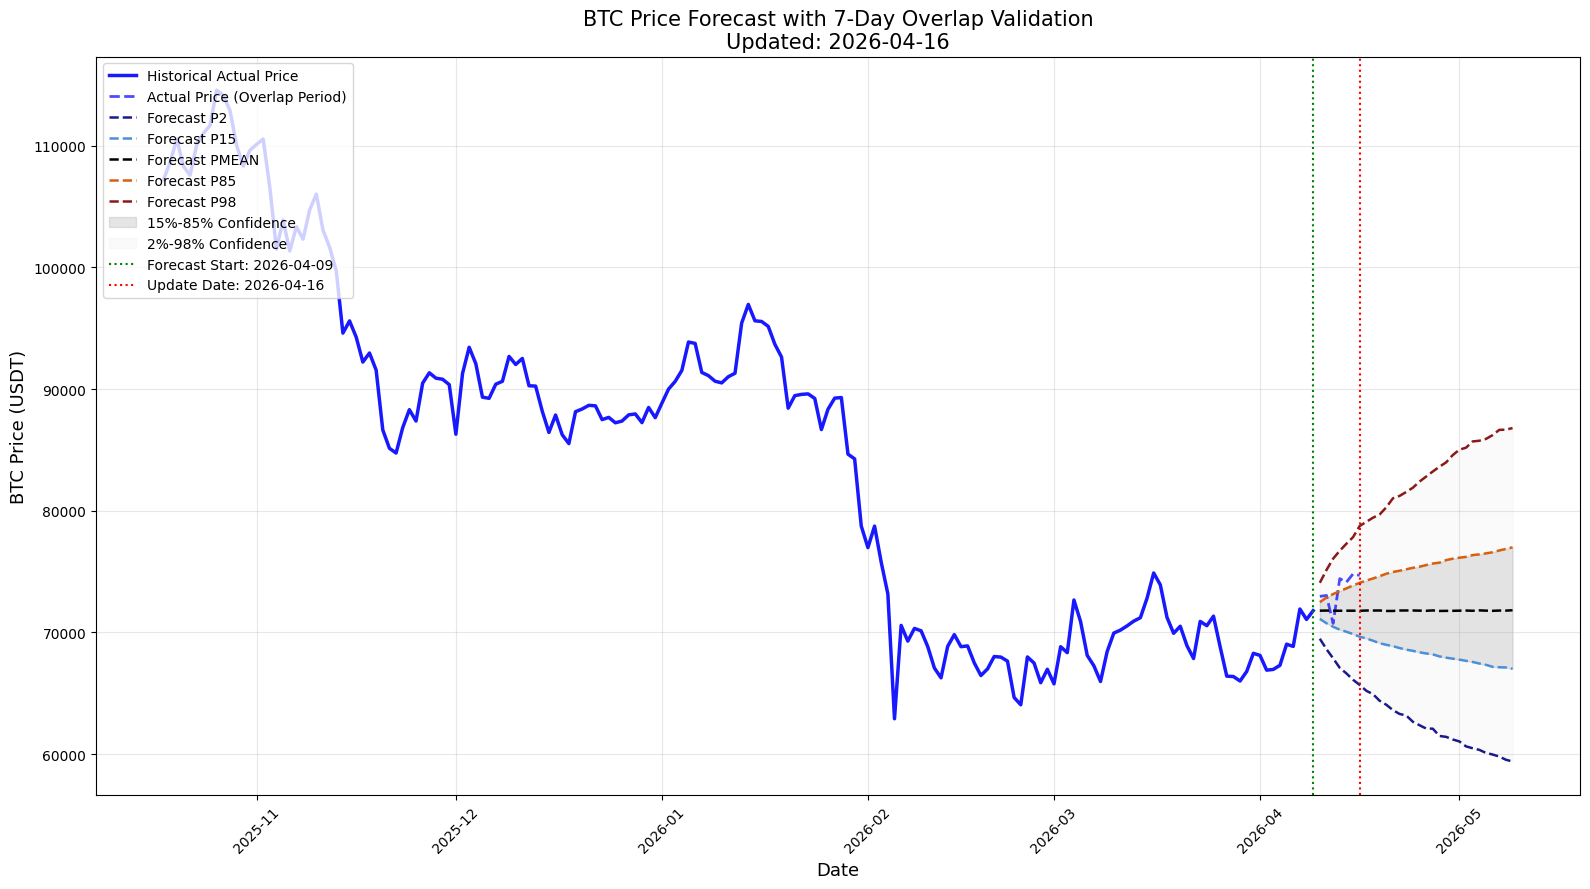


Plot saved as: btc_forecast_track_20260416.png
Summary table saved as: state_summary_20260416.csv
Full results saved as: forecast_result_20260416.json


In [3]:


np.random.seed(7)

# ==================== data loading ====================
def load_btc_data(filepath):
    df = pd.read_csv(filepath)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    return df

def compute_ror(df, price_col='close'):
    df = df.copy()
    df['ror'] = df[price_col].pct_change()
    df['log_return'] = np.log(df[price_col] / df[price_col].shift(1))
    return df

# ==================== HMM regime detect ====================
class HMMRegimeDetector:
    def __init__(self, n_states=3, lookback_window=252):
        self.n_states = n_states
        self.lookback_window = lookback_window
        self.model = None
        self.state_means = None
        self.state_vols = None
        self.fitted = False
        
    def fit(self, df, feature_cols=['ror', 'log_return']):
        features = df[feature_cols].dropna().values
        if len(features) < 50:
            raise ValueError("Insufficient data for HMM training")
        self.model = hmm.GaussianHMM(
            n_components=self.n_states,
            covariance_type='full',
            n_iter=1000,
            tol=1e-3,
            verbose=False,
            random_state=42
        )
        self.model.fit(features)
        states = self.model.predict(features)
        self.state_means = []
        self.state_vols = []
        valid_idx = ~df[feature_cols[0]].isna()
        valid_returns = df.loc[valid_idx, 'ror'].values
        for s in range(self.n_states):
            mask = states == s
            if mask.sum() > 0:
                self.state_means.append(valid_returns[mask].mean())
                self.state_vols.append(valid_returns[mask].std())
            else:
                self.state_means.append(0)
                self.state_vols.append(0.01)
        self.fitted = True
        return self
    
    def get_current_state_proba(self, recent_features):
        if not self.fitted:
            raise ValueError("Model not fitted yet")
        proba = self.model.predict_proba(recent_features)
        return proba[-1]

# ==================== adaptive gbm forecaster(enhanced) ====================
class AdaptiveGBMForecaster:
    def __init__(self, hmm_detector, forecast_days=30, n_simulations=10000,
                 vol_floor_percentile=100,  # btc naturally fluctuation
                 use_t_dist=True, df_t=3,   # keep thick tail
                 momentum_window=10,        # shortened
                 mix_ratio=0.3,             # enlarged
                 jump_intensity=0.05,       
                 jump_scale=0.03):
        self.hmm = hmm_detector
        self.forecast_days = forecast_days
        self.n_simulations = n_simulations
        self.vol_floor_percentile = vol_floor_percentile
        self.use_t_dist = use_t_dist
        self.df_t = df_t
        self.momentum_window = momentum_window
        self.mix_ratio = mix_ratio
        self.jump_intensity = jump_intensity
        self.jump_scale = jump_scale

    def compute_ewma_volatility(self, returns, span=10):  
        if len(returns) < 5:
            return 0.02  # 2%daily fluctuation
        vol = pd.Series(returns).ewm(span=span, adjust=False).std().iloc[-1]
        # short term volatility(enlarged recently due to war)
        vol = vol * 1.2
        return max(vol, 0.005)

    def compute_weighted_params(self, state_proba, historical_returns, recent_returns):
        mu_long = 0.0
        sigma_long = 0.0
        for s in range(self.hmm.n_states):
            mu_long += state_proba[s] * self.hmm.state_means[s]
            sigma_long += state_proba[s] * self.hmm.state_vols[s]

        # short term momentum and volatility
        if len(recent_returns) >= self.momentum_window:
            mu_short = np.mean(recent_returns[-self.momentum_window:])
        else:
            mu_short = mu_long

        sigma_short = self.compute_ewma_volatility(recent_returns)

        # mixed
        mu = self.mix_ratio * mu_long + (1 - self.mix_ratio) * mu_short
        sigma = self.mix_ratio * sigma_long + (1 - self.mix_ratio) * sigma_short

        # moving volatility within historical volatility'smean and greater than 2%
        if len(historical_returns) > 20:
            # computing rolling 20 volatiliy
            rolling_vol = pd.Series(historical_returns).rolling(20).std().dropna()
            if len(rolling_vol) > 0:
                median_vol = np.percentile(rolling_vol, self.vol_floor_percentile)
                sigma_floor = max(median_vol, 0.02)  # hard bottom of volatility at 2%
            else:
                sigma_floor = 0.02
        else:
            sigma_floor = 0.02

        sigma = max(sigma, sigma_floor)

        # if recent volatility is significantly higher than sigma, use recent volatility b/c it is volatility dominated market
        if sigma_short > sigma * 1.5:
            sigma = sigma_short

        return {
            'mu_daily': mu,
            'sigma_daily': sigma,
            'mu_annual': mu * 252,
            'sigma_annual': sigma * np.sqrt(252)
        }

    def simulate_price_paths(self, current_price, mu, sigma):
        dt = 1 / 252
        T = self.forecast_days
        n_steps = T

        # volatility simulator
        mu_samples = mu + np.random.normal(0, sigma * 0.5, self.n_simulations)
        sigma_samples = sigma * np.exp(np.random.normal(0, 0.5, self.n_simulations))
        sigma_samples = np.maximum(sigma_samples, sigma * 0.3)  # can be lower but cannot be lower than 0.3 times

        # random noice(thick tail)
        if self.use_t_dist:
            # t-distributed wit df=3，not normalizing r-squre to keep thick tail
            Z = stats.t.rvs(df=self.df_t, size=(self.n_simulations, n_steps))
        else:
            Z = np.random.randn(self.n_simulations, n_steps)

        # cumulative volatility
        W = np.cumsum(Z, axis=1) * np.sqrt(dt)
        time_steps = np.arange(1, n_steps + 1) * dt
        time_matrix = time_steps.reshape(1, -1)

        price_paths = np.zeros((self.n_simulations, n_steps))
        for i in range(self.n_simulations):
            mu_i = mu_samples[i]
            sigma_i = sigma_samples[i]
            drift = (mu_i - 0.5 * sigma_i**2) * time_matrix
            diffusion = sigma_i * W[i:i+1, :]
            log_returns = drift + diffusion

            # laplace volatility proportional to sigma
            if self.jump_intensity > 0:
                n_jumps = np.random.poisson(self.jump_intensity * n_steps)
                if n_jumps > 0:
                    jump_times = np.random.choice(n_steps, n_jumps, replace=False)
                    jump_sizes = np.random.laplace(0, scale=self.jump_scale * sigma_i, size=n_jumps)
                    for t_idx, jsize in zip(jump_times, jump_sizes):
                        log_returns[0, t_idx:] += jsize

            price_paths[i, :] = current_price * np.exp(log_returns)

        return price_paths

    def forecast_percentiles(self, current_price, state_proba, historical_returns, recent_returns):
        params = self.compute_weighted_params(state_proba, historical_returns, recent_returns)
        mu = params['mu_daily']
        sigma = params['sigma_daily']
        price_paths = self.simulate_price_paths(current_price, mu, sigma)
        percentiles = {}
        for p in [2, 15, 50, 85, 98]:
            percentiles[p] = np.percentile(price_paths, p, axis=0)
        return {
            'p2': percentiles[2],
            'p15': percentiles[15],
            'pmean': percentiles[50],
            'p85': percentiles[85],
            'p98': percentiles[98],
            'params': params
        }

# ==================== summary table ====================
def generate_state_summary(recent_proba_history):
    recent_7d = recent_proba_history.tail(7).copy()
    max_proba = recent_7d['max_proba'].values
    thresholds = {
        '>98%': 0.98, '>85%': 0.85, '>mean': max_proba.mean(),
        '>15%': 0.15, '>2%': 0.02,
        '<98%': 0.98, '<85%': 0.85, '<mean': max_proba.mean(),
        '<15%': 0.15, '<2%': 0.02
    }
    summary_rows = []
    for label, threshold in thresholds.items():
        if label.startswith('>'):
            mask = max_proba > threshold
        else:
            mask = max_proba < threshold
        n_days = mask.sum()
        since_date = recent_7d.loc[mask, 'date'].min() if n_days > 0 else 'N/A'
        summary_rows.append({
            'status': label,
            'number-of-days': n_days,
            'since(date)': since_date
        })
    summary_df = pd.DataFrame(summary_rows)
    between_15_85 = ((max_proba > 0.15) & (max_proba < 0.85)).sum()
    between_2_98 = ((max_proba > 0.02) & (max_proba < 0.98)).sum()
    summary_df.loc[len(summary_df)] = {
        'status': 'Between 15%-85%', 'number-of-days': between_15_85, 'since(date)': 'N/A'
    }
    summary_df.loc[len(summary_df)] = {
        'status': 'Between 2%-98%', 'number-of-days': between_2_98, 'since(date)': 'N/A'
    }
    return summary_df

# ==================== daily plot ====================
def plot_performance_track_overlap(df, forecast_result, update_date, 
                                   history_days=180, forecast_days=30, overlap_days=7):
    fig, ax = plt.subplots(figsize=(16, 9))
    update_date = pd.to_datetime(update_date)
    forecast_start = update_date - timedelta(days=overlap_days)
    history_end = forecast_start
    start_date = update_date - timedelta(days=history_days)
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    hist_mask = (df['timestamp'] >= start_date) & (df['timestamp'] <= history_end)
    hist_df = df.loc[hist_mask].copy()
    ax.plot(hist_df['timestamp'], hist_df['close'], 'b-', linewidth=2.5, 
            label='Historical Actual Price', alpha=0.9)
    
    overlap_mask = (df['timestamp'] > history_end) & (df['timestamp'] <= update_date)
    overlap_df = df.loc[overlap_mask].copy()
    if not overlap_df.empty:
        ax.plot(overlap_df['timestamp'], overlap_df['close'], 'b--', linewidth=2, 
                label='Actual Price (Overlap Period)', alpha=0.7)
    
    current_price = hist_df['close'].iloc[-1] if not hist_df.empty else overlap_df['close'].iloc[0]
    forecast_dates = [forecast_start + timedelta(days=i+1) for i in range(forecast_days)]
    
    colors = {'p2': '#1a1a8a', 'p15': '#4a90d9', 'pmean': '#000000', 
              'p85': '#d95f0e', 'p98': '#8a1a1a'}
    for key, color in colors.items():
        if key in forecast_result:
            forecast_prices = forecast_result[key]
            ax.plot(forecast_dates, forecast_prices, '--', color=color, linewidth=1.8,
                   label=f'Forecast {key.upper()}')
    
    if 'p15' in forecast_result and 'p85' in forecast_result:
        ax.fill_between(forecast_dates, forecast_result['p15'], forecast_result['p85'],
                        alpha=0.2, color='gray', label='15%-85% Confidence')
    if 'p2' in forecast_result and 'p98' in forecast_result:
        ax.fill_between(forecast_dates, forecast_result['p2'], forecast_result['p98'],
                        alpha=0.1, color='lightgray', label='2%-98% Confidence')
    
    ax.axvline(x=forecast_start, color='green', linestyle=':', linewidth=1.5,
              label=f'Forecast Start: {forecast_start.date()}')
    ax.axvline(x=update_date, color='red', linestyle=':', linewidth=1.5,
              label=f'Update Date: {update_date.date()}')
    
    ax.set_xlabel('Date', fontsize=13)
    ax.set_ylabel('BTC Price (USDT)', fontsize=13)
    ax.set_title(f'BTC Price Forecast with 7-Day Overlap Validation\n'
                 f'Updated: {update_date.date()}', fontsize=15)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig, ax

# ==================== daily update engine ====================
class DailyUpdateEngine:
    def __init__(self, df, n_states=3, lookback_days=252,
                 forecast_days=30, n_simulations=10000, overlap_days=7):
        self.df = df.copy()
        self.df['timestamp'] = pd.to_datetime(self.df['timestamp'])
        self.n_states = n_states
        self.lookback_days = lookback_days
        self.forecast_days = forecast_days
        self.n_simulations = n_simulations
        self.overlap_days = overlap_days
        
        self.df = compute_ror(self.df)
        self.proba_history = []
        self.hmm_detector = HMMRegimeDetector(n_states=n_states, lookback_window=lookback_days)
        self.forecaster = None
        
    def train_initial_model(self):
        self.hmm_detector.fit(self.df)
        self.forecaster = AdaptiveGBMForecaster(
            self.hmm_detector,
            forecast_days=self.forecast_days,
            n_simulations=self.n_simulations
        )
        
    def update_daily(self, update_date):
        update_date = pd.to_datetime(update_date)
        forecast_start = update_date - timedelta(days=self.overlap_days)
        
        mask = self.df['timestamp'] <= update_date
        current_df = self.df.loc[mask].copy()
        if len(current_df) < 50:
            raise ValueError(f"Not enough data for {update_date}")
        
        self.hmm_detector.fit(current_df)
        self.forecaster = AdaptiveGBMForecaster(
            self.hmm_detector,
            forecast_days=self.forecast_days,
            n_simulations=self.n_simulations
        )
        
        recent_features = current_df[['ror', 'log_return']].dropna().values[-10:]
        if len(recent_features) > 0:
            state_proba = self.hmm_detector.get_current_state_proba(recent_features)
        else:
            state_proba = np.ones(self.n_states) / self.n_states
        
        forecast_start_price = current_df[current_df['timestamp'] <= forecast_start]['close'].iloc[-1]
        historical_returns = current_df['ror'].dropna().values
        recent_returns = current_df['ror'].dropna().values[-50:]
        
        forecast_result = self.forecaster.forecast_percentiles(
            forecast_start_price, state_proba, historical_returns, recent_returns
        )
        
        max_proba = np.max(state_proba)
        self.proba_history.append({
            'date': update_date,
            'max_proba': max_proba,
            'dominant_state': np.argmax(state_proba),
            'state_proba': state_proba.tolist()
        })
        
        confidence = self._compute_trading_confidence(state_proba, forecast_result['params'])
        proba_df = pd.DataFrame(self.proba_history)
        summary_table = generate_state_summary(proba_df) if len(proba_df) >= 7 else pd.DataFrame()
        
        return {
            'update_date': update_date,
            'forecast_start': forecast_start,
            'forecast_start_price': forecast_start_price,
            'state_proba': state_proba,
            'forecast': forecast_result,
            'params': forecast_result['params'],
            'summary_table': summary_table,
            'trading_confidence': confidence,
            'current_df': current_df
        }
    
    def _compute_trading_confidence(self, state_proba, params):
        mu = params['mu_daily']
        sigma = params['sigma_daily']
        sharpe = mu / sigma if sigma > 0 else 0
        max_proba = np.max(state_proba)
        if mu > 0.0005:
            signal = 'LONG'
            base_confidence = max_proba
        elif mu < -0.0005:
            signal = 'SHORT'
            base_confidence = max_proba
        else:
            signal = 'NEUTRAL'
            base_confidence = max_proba * 0.5
        sharpe_factor = min(abs(sharpe) / 2, 1.0) if sigma > 0 else 0
        adjusted_confidence = base_confidence * (0.5 + 0.5 * sharpe_factor)
        return {
            'signal': signal,
            'confidence': adjusted_confidence,
            'max_proba': max_proba,
            'mu_daily': mu,
            'sigma_daily': sigma,
            'sharpe': sharpe
        }
    
    def run_simulation(self, start_date, end_date=None):
        if end_date is None:
            end_date = self.df['timestamp'].max()
        start_date = pd.to_datetime(start_date)
        end_date = pd.to_datetime(end_date)
        
        initial_df = self.df[self.df['timestamp'] < start_date].copy()
        if len(initial_df) > self.lookback_days:
            self.hmm_detector.fit(initial_df)
            self.forecaster = AdaptiveGBMForecaster(
                self.hmm_detector,
                forecast_days=self.forecast_days,
                n_simulations=self.n_simulations
            )
        
        update_dates = pd.date_range(start=start_date, end=end_date, freq='D')
        results = []
        for update_date in update_dates:
            if update_date in self.df['timestamp'].values:
                try:
                    result = self.update_daily(update_date)
                    results.append(result)
                    tc = result['trading_confidence']
                   
                    print(f"Updated: {update_date.date()} | Signal: {tc['signal']} | "
                          f"Conf: {tc['confidence']:.2%} | MaxProb: {tc['max_proba']:.2%} | "
                          f"σ_daily: {tc['sigma_daily']:.4f} (ann: {tc['sigma_daily']*np.sqrt(252):.1%})")
                except Exception as e:
                    print(f"Error on {update_date.date()}: {e}")
        return results

# ====================MAIN====================
def main():
    DATA_FILE = 'BTCUSDT_1d_1_Jan_2017.csv'
    N_STATES = 3
    LOOKBACK_DAYS = 252
    FORECAST_DAYS = 30
    N_SIMULATIONS = 10000
    OVERLAP_DAYS = 7
    
    print("Loading BTC data...")
    df = load_btc_data(DATA_FILE)
    print(f"Loaded {len(df)} days from {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
    
    engine = DailyUpdateEngine(
        df=df,
        n_states=N_STATES,
        lookback_days=LOOKBACK_DAYS,
        forecast_days=FORECAST_DAYS,
        n_simulations=N_SIMULATIONS,
        overlap_days=OVERLAP_DAYS
    )
    
    end_date = df['timestamp'].max()
    start_date = end_date - timedelta(days=30)
    print(f"\nRunning daily updates from {start_date.date()} to {end_date.date()}...")
    print("-" * 70)
    
    results = engine.run_simulation(start_date, end_date)
    
    if results:
        latest = results[-1]
        date_str = latest['update_date'].strftime('%Y%m%d')
        
        print("\n" + "=" * 70)
        print(f"LATEST UPDATE: {latest['update_date'].date()}")
        print("=" * 70)
        print("\n=== STATE SUMMARY TABLE (Last 7 Days) ===")
        print(latest['summary_table'].to_string(index=False))
        
        tc = latest['trading_confidence']
        print("\n=== TRADING CONFIDENCE ===")
        print(f"Signal:      {tc['signal']}")
        print(f"Confidence:  {tc['confidence']:.2%}")
        print(f"Max Proba:   {tc['max_proba']:.2%}")
        print(f"Daily μ:     {tc['mu_daily']:.6f} ({tc['mu_daily']*252:.2%} annual)")
        print(f"Daily σ:     {tc['sigma_daily']:.6f} ({tc['sigma_daily']*np.sqrt(252):.2%} annual)")
        print(f"Sharpe:      {tc['sharpe']:.4f}")
        
        fig, ax = plot_performance_track_overlap(
            df, latest['forecast'], latest['update_date'],
            history_days=180, forecast_days=FORECAST_DAYS, overlap_days=OVERLAP_DAYS
        )
        
        plot_filename = f'btc_forecast_track_{date_str}.png'
        plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\nPlot saved as: {plot_filename}")
        
        summary_filename = f'state_summary_{date_str}.csv'
        latest['summary_table'].to_csv(summary_filename, index=False)
        print(f"Summary table saved as: {summary_filename}")
        
        result_json = {
            'update_date': str(latest['update_date'].date()),
            'forecast_start': str(latest['forecast_start'].date()),
            'forecast_start_price': latest['forecast_start_price'],
            'state_proba': latest['state_proba'].tolist(),
            'params': {k: float(v) if isinstance(v, np.float64) else v for k, v in latest['params'].items()},
            'trading_confidence': {k: float(v) if isinstance(v, np.float64) else v for k, v in tc.items()},
            'forecast_p2': latest['forecast']['p2'].tolist(),
            'forecast_p15': latest['forecast']['p15'].tolist(),
            'forecast_pmean': latest['forecast']['pmean'].tolist(),
            'forecast_p85': latest['forecast']['p85'].tolist(),
            'forecast_p98': latest['forecast']['p98'].tolist(),
        }
        json_filename = f'forecast_result_{date_str}.json'
        with open(json_filename, 'w') as f:
            json.dump(result_json, f, indent=2)
        print(f"Full results saved as: {json_filename}")
        
        proba_hist_df = pd.DataFrame(engine.proba_history)
        proba_hist_df.to_csv(f'state_proba_history_{date_str}.csv', index=False)
        
    return engine, results

if __name__ == "__main__":
    engine, results = main()